---
## Default Header
---

In [5]:
import os, copy, random
print(os.listdir("/kaggle/input"))

['ovarian-cancer-classification-dataset']


In [6]:
import os
from glob import glob

BASE = "/kaggle/input/ovarian-cancer-classification-dataset"

# Find Train_Images automatically
def find_train_dir(base):
    for r, d, _ in os.walk(base):
        if "Train_Images" in d:
            return os.path.join(r, "Train_Images")
    raise RuntimeError("Train_Images not found")

train_root = find_train_dir(BASE)

print("Train folder:", train_root)
print("\nClass-wise image count:\n")

total = 0

for cls in sorted(os.listdir(train_root)):
    cls_path = os.path.join(train_root, cls)
    if os.path.isdir(cls_path):
        count = len(glob(os.path.join(cls_path, "*")))
        total += count
        print(f"{cls} : {count}")

print("\nTotal images:", total)


Train folder: /kaggle/input/ovarian-cancer-classification-dataset/Train_Images

Class-wise image count:

CC : 5579
EC : 7421
HGSC : 12019
LGSC : 2908
MC : 3276

Total images: 31203


In [7]:
import os
import numpy as np
from glob import glob
from sklearn.model_selection import StratifiedKFold

BASE = "/kaggle/input/ovarian-cancer-classification-dataset"

# -----------------------------
# Locate Train_Images
# -----------------------------
def find_train_dir(base):
    for r, d, _ in os.walk(base):
        if "Train_Images" in d:
            return os.path.join(r, "Train_Images")
    raise RuntimeError("Train_Images not found")

train_root = find_train_dir(BASE)

classes = sorted([d for d in os.listdir(train_root)
                  if os.path.isdir(os.path.join(train_root, d))])

cls_to_idx = {c:i for i,c in enumerate(classes)}

# -----------------------------
# Count class sizes
# -----------------------------
class_counts = {}

for c in classes:
    count = len(glob(os.path.join(train_root, c, "*")))
    class_counts[c] = count

min_count = min(class_counts.values())

print("Original class distribution:")
for c in classes:
    print(f"{c}: {class_counts[c]}")

print("\nMinimum class count (for balancing):", min_count)

# -----------------------------
# Create balanced dataset
# -----------------------------
files, labels = [], []

np.random.seed(42)

for c in classes:
    all_files = glob(os.path.join(train_root, c, "*"))
    selected = np.random.choice(all_files, min_count, replace=False)
    files.extend(selected)
    labels.extend([cls_to_idx[c]] * min_count)

files = np.array(files)
labels = np.array(labels)

print("\nBalanced dataset size:", len(files))
print("Images per class:", min_count)

# -----------------------------
# 5-Fold Stratified Cross Validation
# -----------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nCross-validation class distribution per fold:\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(files, labels), 1):

    train_labels = labels[train_idx]
    val_labels   = labels[val_idx]

    print(f"Fold {fold}")
    for i, c in enumerate(classes):
        print(f"  {c} → Train: {np.sum(train_labels==i)}, "
              f"Val: {np.sum(val_labels==i)}")
    print()

Original class distribution:
CC: 5579
EC: 7421
HGSC: 12019
LGSC: 2908
MC: 3276

Minimum class count (for balancing): 2908

Balanced dataset size: 14540
Images per class: 2908

Cross-validation class distribution per fold:

Fold 1
  CC → Train: 2326, Val: 582
  EC → Train: 2326, Val: 582
  HGSC → Train: 2327, Val: 581
  LGSC → Train: 2326, Val: 582
  MC → Train: 2327, Val: 581

Fold 2
  CC → Train: 2326, Val: 582
  EC → Train: 2327, Val: 581
  HGSC → Train: 2326, Val: 582
  LGSC → Train: 2326, Val: 582
  MC → Train: 2327, Val: 581

Fold 3
  CC → Train: 2326, Val: 582
  EC → Train: 2327, Val: 581
  HGSC → Train: 2326, Val: 582
  LGSC → Train: 2327, Val: 581
  MC → Train: 2326, Val: 582

Fold 4
  CC → Train: 2327, Val: 581
  EC → Train: 2326, Val: 582
  HGSC → Train: 2326, Val: 582
  LGSC → Train: 2327, Val: 581
  MC → Train: 2326, Val: 582

Fold 5
  CC → Train: 2327, Val: 581
  EC → Train: 2326, Val: 582
  HGSC → Train: 2327, Val: 581
  LGSC → Train: 2326, Val: 582
  MC → Train: 2326, Va

---
## Main Pipeline
---


================ DATA SUMMARY ================
Total Images: 34285
Classes: [np.str_('CC'), np.str_('EC'), np.str_('HGSC'), np.str_('LGSC'), np.str_('MC')]


            FOLD 1


Fold 1 Epoch 1: 100%|██████████| 286/286 [04:30<00:00,  1.06it/s]



Epoch 1 Accuracy: 0.8177


Fold 1 Epoch 2: 100%|██████████| 286/286 [02:08<00:00,  2.22it/s]



Epoch 2 Accuracy: 0.8648


...


Epoch 8 Accuracy: 0.9357


Fold 1 Epoch 9: 100%|██████████| 286/286 [02:05<00:00,  2.28it/s]



Epoch 9 Accuracy: 0.9383


Fold 1 Epoch 10: 100%|██████████| 286/286 [02:09<00:00,  2.20it/s]



Epoch 10 Accuracy: 0.9393

========== FOLD RESULT ==========
Accuracy: 0.9393 | BAcc: 0.9322 | F1: 0.9328 | AUC: 0.9960


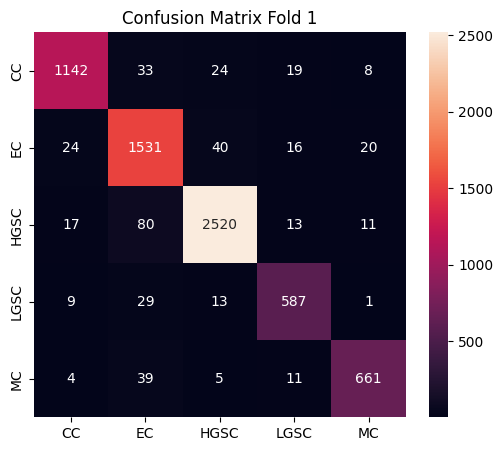


            FOLD 2


Fold 2 Epoch 1: 100%|██████████| 286/286 [02:06<00:00,  2.25it/s]



Epoch 1 Accuracy: 0.7923


Fold 2 Epoch 2: 100%|██████████| 286/286 [02:05<00:00,  2.27it/s]



Epoch 2 Accuracy: 0.8526


...


Epoch 8 Accuracy: 0.9322


Fold 2 Epoch 9: 100%|██████████| 286/286 [02:14<00:00,  2.12it/s]



Epoch 9 Accuracy: 0.9322


Fold 2 Epoch 10: 100%|██████████| 286/286 [02:13<00:00,  2.14it/s]



Epoch 10 Accuracy: 0.9328

========== FOLD RESULT ==========
Accuracy: 0.9328 | BAcc: 0.9230 | F1: 0.9241 | AUC: 0.9951


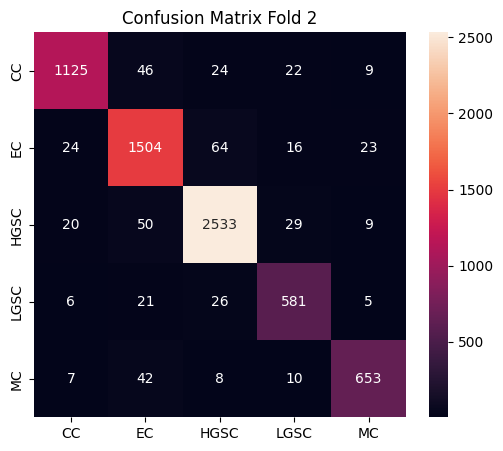


            FOLD 3


Fold 3 Epoch 1: 100%|██████████| 286/286 [02:14<00:00,  2.13it/s]



Epoch 1 Accuracy: 0.8012


Fold 3 Epoch 2: 100%|██████████| 286/286 [02:13<00:00,  2.14it/s]



Epoch 2 Accuracy: 0.8587


...


Epoch 8 Accuracy: 0.9265


Fold 3 Epoch 9: 100%|██████████| 286/286 [02:08<00:00,  2.22it/s]



Epoch 9 Accuracy: 0.9265


Fold 3 Epoch 10: 100%|██████████| 286/286 [02:09<00:00,  2.21it/s]



Epoch 10 Accuracy: 0.9293

========== FOLD RESULT ==========
Accuracy: 0.9293 | BAcc: 0.9233 | F1: 0.9203 | AUC: 0.9949


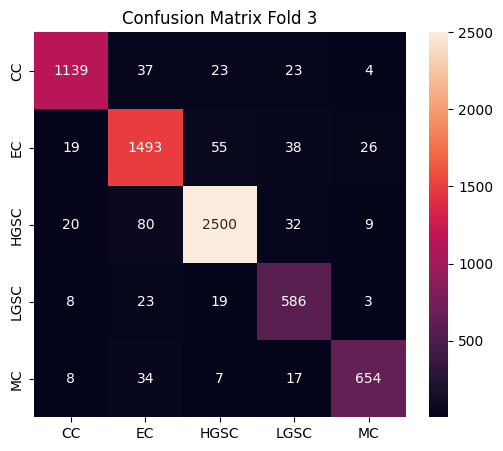


            FOLD 4


Fold 4 Epoch 1: 100%|██████████| 286/286 [02:08<00:00,  2.23it/s]



Epoch 1 Accuracy: 0.8018


Fold 4 Epoch 2: 100%|██████████| 286/286 [02:07<00:00,  2.24it/s]



Epoch 2 Accuracy: 0.8505


...


Epoch 8 Accuracy: 0.9177


Fold 4 Epoch 9: 100%|██████████| 286/286 [02:04<00:00,  2.29it/s]



Epoch 9 Accuracy: 0.9201


Fold 4 Epoch 10: 100%|██████████| 286/286 [02:05<00:00,  2.28it/s]



Epoch 10 Accuracy: 0.9242

========== FOLD RESULT ==========
Accuracy: 0.9242 | BAcc: 0.9148 | F1: 0.9115 | AUC: 0.9942


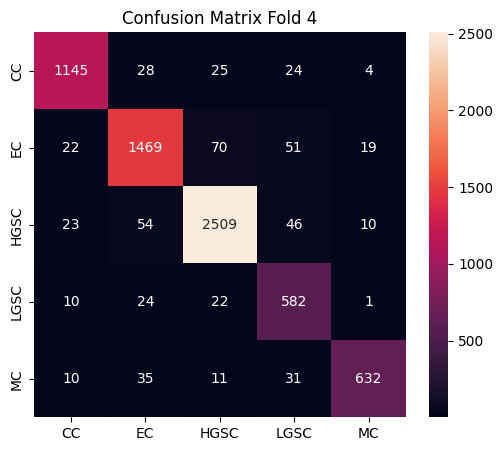


            FOLD 5


Fold 5 Epoch 1: 100%|██████████| 286/286 [02:05<00:00,  2.28it/s]



Epoch 1 Accuracy: 0.7894


Fold 5 Epoch 2: 100%|██████████| 286/286 [02:05<00:00,  2.27it/s]



Epoch 2 Accuracy: 0.8496


...


Epoch 8 Accuracy: 0.9252


Fold 5 Epoch 9: 100%|██████████| 286/286 [02:05<00:00,  2.27it/s]



Epoch 9 Accuracy: 0.9288


Fold 5 Epoch 10: 100%|██████████| 286/286 [02:04<00:00,  2.31it/s]



Epoch 10 Accuracy: 0.9297

========== FOLD RESULT ==========
Accuracy: 0.9297 | BAcc: 0.9228 | F1: 0.9222 | AUC: 0.9946


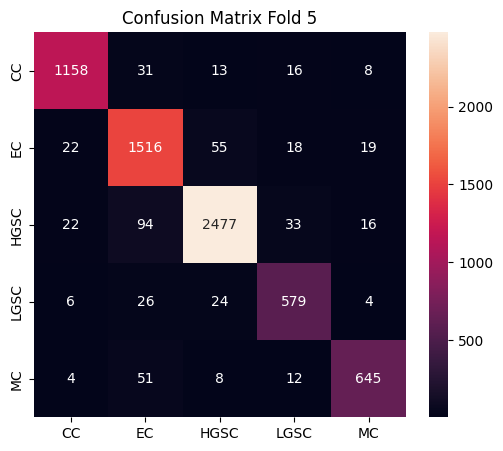


        FINAL 5-FOLD CROSS VALIDATION RESULTS
Accuracy          : 0.9310 ± 0.0050
Balanced Accuracy : 0.9232 ± 0.0055
Macro F1          : 0.9222 ± 0.0068
Macro AUC         : 0.9949 ± 0.0006
CI Accuracy   : [0.9241, 0.9380]


In [8]:
# ============================================================
# FINAL HISTOPATHOLOGY PIPELINE (OPTIMIZED)
# EfficientNet-B0 + SE Attention
# Dataset Caching + Faster IO
# 5-Fold CV + AMP + tqdm
# Structured Output
# ============================================================

import os, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torchvision.io import read_image

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# ---------------- FLAGS ----------------
USE_AUG = True
FREEZE_BACKBONE = False
USE_SE = True

BATCH_SIZE = 96
EPOCHS = 10

# ---------------- SE BLOCK ----------------
class SEBlock(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(ch, ch//r),
            nn.ReLU(),
            nn.Linear(ch//r, ch),
            nn.Sigmoid()
        )
    def forward(self,x):
        b,c,_,_ = x.shape
        y = self.pool(x).view(b,c)
        y = self.fc(y).view(b,c,1,1)
        return x*y

# ---------------- MODEL ----------------
class EfficientNetSE(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.se = SEBlock(1280) if USE_SE else nn.Identity()
        self.backbone.classifier[1] = nn.Linear(1280,num_classes)

    def forward(self,x):
        x = self.backbone.features(x)
        x = self.se(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x,1)
        x = self.backbone.classifier(x)
        return x

# ---------------- DATA LOADING ----------------
BASE = "/kaggle/input/ovarian-cancer-classification-dataset"

def collect_images(base):
    f,l = [],[]
    for split in ["Train_Images","Test_Images"]:
        for cls in os.listdir(os.path.join(base,split)):
            p = os.path.join(base,split,cls)
            if os.path.isdir(p):
                imgs = glob(os.path.join(p,"*"))
                f.extend(imgs)
                l.extend([cls]*len(imgs))
    return np.array(f),np.array(l)

files, labels_str = collect_images(BASE)
classes = sorted(np.unique(labels_str))
cls_to_idx = {c:i for i,c in enumerate(classes)}
labels = np.array([cls_to_idx[i] for i in labels_str])

print("\n================ DATA SUMMARY ================")
print("Total Images:", len(files))
print("Classes:", classes)
print("=============================================\n")

# ---------------- DATASET (CACHED + FAST IO) ----------------
class HistoDataset(Dataset):
    def __init__(self, files, labels, tf):
        self.files=files; self.labels=labels; self.tf=tf
        self.cache={}

    def __len__(self): return len(self.files)

    def __getitem__(self,i):
        if i in self.cache:
            return self.cache[i]

        img = read_image(self.files[i]).float()/255.0
        img = self.tf(img)
        sample = (img,self.labels[i])
        self.cache[i]=sample
        return sample

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2,0.2,0.2)
]) if USE_AUG else transforms.Compose([
    transforms.Resize((224,224))
])

val_tf = transforms.Compose([
    transforms.Resize((224,224))
])

# ---------------- TRAINING ----------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_acc, fold_bacc, fold_f1, fold_auc = [],[],[],[]

for fold,(tr,va) in enumerate(skf.split(files,labels),1):

    print(f"\n{'='*55}\n            FOLD {fold}\n{'='*55}")

    train_ds = HistoDataset(files[tr],labels[tr],train_tf)
    val_ds   = HistoDataset(files[va],labels[va],val_tf)

    train_loader = DataLoader(train_ds,BATCH_SIZE,True,num_workers=2,pin_memory=True)
    val_loader   = DataLoader(val_ds,BATCH_SIZE,False,num_workers=2,pin_memory=True)

    model = EfficientNetSE(len(classes)).to(device)

    if FREEZE_BACKBONE:
        for p in model.backbone.features.parameters():
            p.requires_grad=False

    optimizer = optim.AdamW(model.parameters(),lr=3e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,EPOCHS)
    scaler = torch.cuda.amp.GradScaler()
    criterion = nn.CrossEntropyLoss()

    best=0

    for epoch in range(EPOCHS):

        model.train()
        for x,y in tqdm(train_loader,desc=f"Fold {fold} Epoch {epoch+1}"):
            x,y = x.to(device,non_blocking=True), y.to(device,non_blocking=True)

            optimizer.zero_grad()
            with torch.amp.autocast("cuda"):
                out = model(x)
                loss = criterion(out,y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        scheduler.step()

        # VALIDATION
        model.eval()
        preds,gts,probs=[],[],[]

        with torch.no_grad():
            for x,y in val_loader:
                x,y = x.to(device),y.to(device)
                with torch.amp.autocast("cuda"):
                    out=model(x)

                p = out.softmax(1)
                probs.extend(p.cpu().numpy())
                preds.extend(out.argmax(1).cpu().numpy())
                gts.extend(y.cpu().numpy())

        acc = accuracy_score(gts,preds)
        print(f"\nEpoch {epoch+1} Accuracy: {acc:.4f}")

        if acc>best:
            best=acc
            torch.save(model.state_dict(),f"best_fold{fold}.pth")

    # METRICS
    acc  = accuracy_score(gts,preds)
    bacc = balanced_accuracy_score(gts,preds)
    f1m  = f1_score(gts,preds,average="macro")
    auc  = roc_auc_score(label_binarize(gts,classes=range(len(classes))),probs,average="macro",multi_class="ovr")

    fold_acc.append(acc); fold_bacc.append(bacc); fold_f1.append(f1m); fold_auc.append(auc)

    print("\n========== FOLD RESULT ==========")
    print(f"Accuracy: {acc:.4f} | BAcc: {bacc:.4f} | F1: {f1m:.4f} | AUC: {auc:.4f}")

    cm = confusion_matrix(gts,preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,fmt="d",xticklabels=classes,yticklabels=classes)
    plt.title(f"Confusion Matrix Fold {fold}")
    plt.show()

# ---------------- FINAL SUMMARY ----------------
mean_acc,std_acc = np.mean(fold_acc),np.std(fold_acc)
ci = stats.t.interval(0.95,len(fold_acc)-1,loc=mean_acc,scale=stats.sem(fold_acc))

print("\n" + "="*60)
print("        FINAL 5-FOLD CROSS VALIDATION RESULTS")
print("="*60)
print(f"Accuracy          : {mean_acc:.4f} ± {std_acc:.4f}")
print(f"Balanced Accuracy : {np.mean(fold_bacc):.4f} ± {np.std(fold_bacc):.4f}")
print(f"Macro F1          : {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f}")
print(f"Macro AUC         : {np.mean(fold_auc):.4f} ± {np.std(fold_auc):.4f}")
print(f"CI Accuracy   : [{ci[0]:.4f}, {ci[1]:.4f}]")
print("="*60)

---
## Final Output
---


Generating FINAL visualizations...


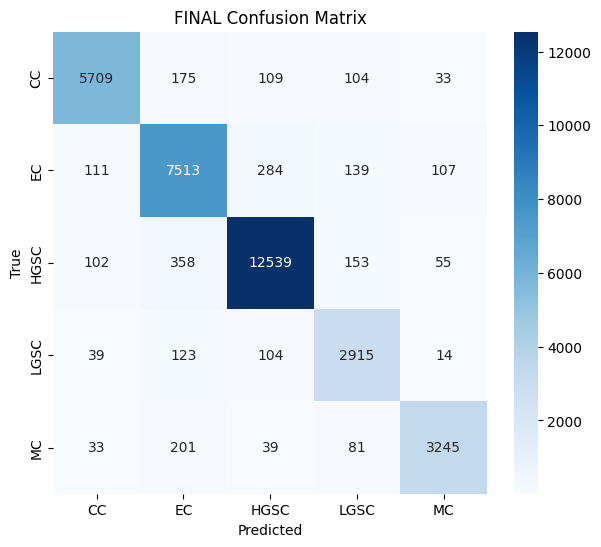

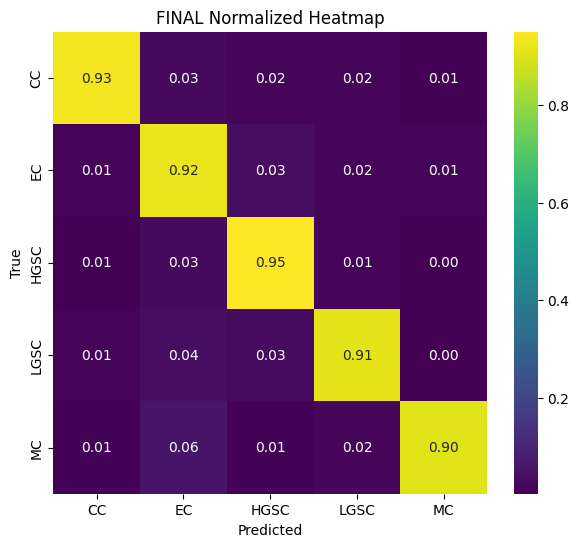

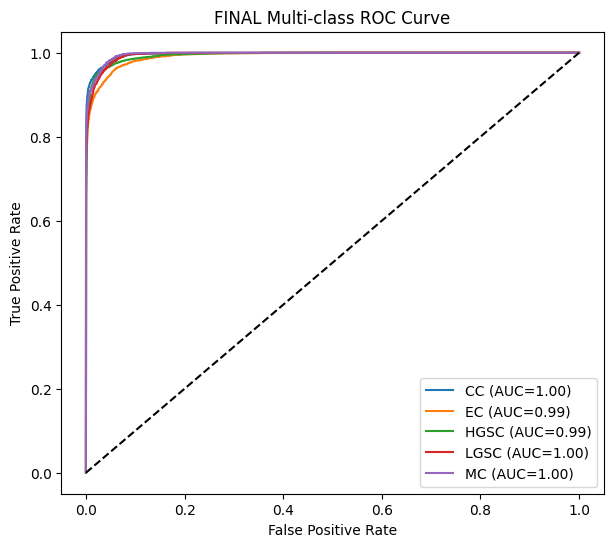

In [9]:
# =============================================================
# FINAL VISUAL OUTPUTS (CONFUSION MATRIX + HEATMAP + ROC CURVE)
# =============================================================

print("\nGenerating FINAL visualizations...")

# Recompute predictions across all folds using saved best models
all_preds, all_gts, all_probs = [], [], []

for fold,(tr,va) in enumerate(skf.split(files,labels),1):

    model = EfficientNetSE(len(classes)).to(device)
    model.load_state_dict(torch.load(f"best_fold{fold}.pth", map_location=device))
    model.eval()

    val_ds = HistoDataset(files[va],labels[va],val_tf)
    val_loader = DataLoader(val_ds,BATCH_SIZE,False)

    with torch.no_grad():
        for x,y in val_loader:
            x = x.to(device)
            with torch.amp.autocast("cuda"):
                out = model(x)

            p = out.softmax(1).cpu().numpy()
            all_probs.extend(p)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_gts.extend(y.numpy())

# ---------------- FINAL CONFUSION MATRIX ----------------
cm = confusion_matrix(all_gts,all_preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=classes,yticklabels=classes,cmap="Blues")
plt.title("FINAL Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---------------- FINAL HEATMAP (NORMALIZED) ----------------
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))
sns.heatmap(cm_norm,annot=True,fmt=".2f",xticklabels=classes,yticklabels=classes,cmap="viridis")
plt.title("FINAL Normalized Heatmap")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---------------- FINAL ROC CURVE ----------------
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(all_gts, classes=range(len(classes)))

plt.figure(figsize=(7,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], np.array(all_probs)[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("FINAL Multi-class ROC Curve")
plt.legend()
plt.show()


Generating FINAL visualizations...


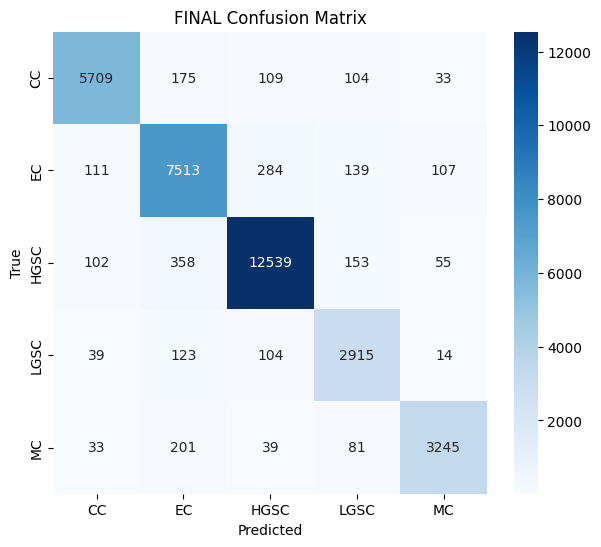

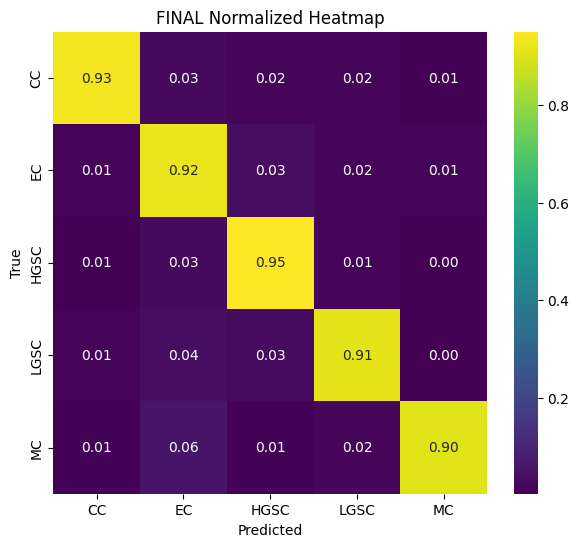

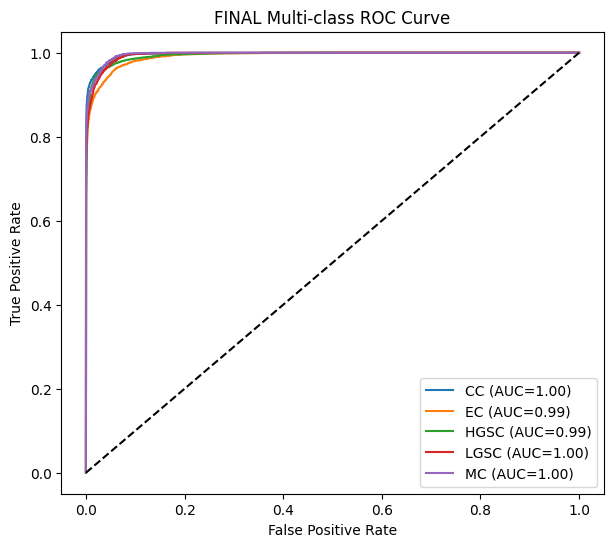

In [10]:
# =============================================================
# FINAL VISUAL OUTPUTS (CONFUSION MATRIX + HEATMAP + ROC CURVE)
# =============================================================

print("\nGenerating FINAL visualizations...")

# Recompute predictions across all folds using saved best models
all_preds, all_gts, all_probs = [], [], []

for fold,(tr,va) in enumerate(skf.split(files,labels),1):

    model = EfficientNetSE(len(classes)).to(device)
    model.load_state_dict(torch.load(f"best_fold{fold}.pth", map_location=device))
    model.eval()

    val_ds = HistoDataset(files[va],labels[va],val_tf)
    val_loader = DataLoader(val_ds,BATCH_SIZE,False)

    with torch.no_grad():
        for x,y in val_loader:
            x = x.to(device)
            with torch.amp.autocast("cuda"):
                out = model(x)

            p = out.softmax(1).cpu().numpy()
            all_probs.extend(p)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_gts.extend(y.numpy())

# ---------------- FINAL CONFUSION MATRIX ----------------
cm = confusion_matrix(all_gts,all_preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=classes,yticklabels=classes,cmap="Blues")
plt.title("FINAL Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---------------- FINAL HEATMAP (NORMALIZED) ----------------
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))
sns.heatmap(cm_norm,annot=True,fmt=".2f",xticklabels=classes,yticklabels=classes,cmap="viridis")
plt.title("FINAL Normalized Heatmap")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---------------- FINAL ROC CURVE ----------------
from sklearn.metrics import roc_curve, auc

y_true_bin = label_binarize(all_gts, classes=range(len(classes)))

plt.figure(figsize=(7,6))

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], np.array(all_probs)[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("FINAL Multi-class ROC Curve")
plt.legend()
plt.show()

---
## SE Block
---

In [11]:
# ===== Re-define SE block =====
class SEBlock(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(ch, ch//r),
            nn.ReLU(),
            nn.Linear(ch//r, ch),
            nn.Sigmoid()
        )

    def forward(self, x):
        b,c,_,_ = x.shape
        y = self.pool(x).view(b,c)
        y = self.fc(y).view(b,c,1,1)
        return x*y

# ===== Re-define EfficientNet+SE =====
class EfficientNetSE(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.se = SEBlock(1280)
        self.backbone.classifier[1] = nn.Linear(1280, num_classes)

    def forward(self, x):
        x = self.backbone.features(x)
        x = self.se(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x,1)
        x = self.backbone.classifier(x)
        return x

---
## GRAD CAM
---

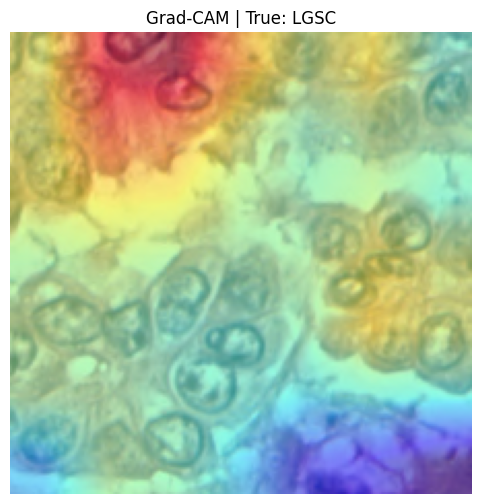

[ WARN:0@0.859] global loadsave.cpp:1063 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

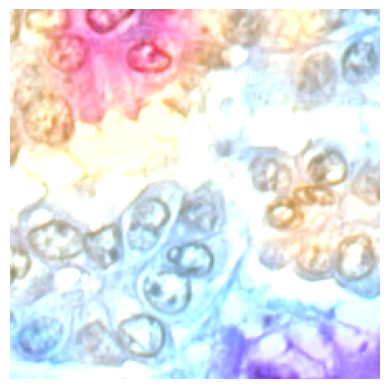

In [12]:
# ============================================================
# GRAD-CAM (POST-TRAINING EXPLAINABILITY)
# Generates overlay heatmap for validation image
# ============================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# -------- LOAD TRAINED MODEL --------
fold = 1  # change fold number if needed
model = EfficientNetSE(len(classes)).to(device)
model.load_state_dict(torch.load(f"best_fold{fold}.pth", map_location=device))
model.eval()

# -------- GRAD-CAM CLASS --------
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.forward_hook)
        target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, input_tensor, class_idx=None):
        self.model.zero_grad()

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        loss = output[:, class_idx]
        loss.backward()

        grads = self.gradients[0].cpu().data.numpy()
        acts = self.activations[0].cpu().data.numpy()

        weights = np.mean(grads, axis=(1,2))
        cam = np.zeros(acts.shape[1:], dtype=np.float32)

        for i, w in enumerate(weights):
            cam += w * acts[i]

        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (224,224))
        cam = cam - cam.min()
        cam = cam / cam.max()

        return cam

# -------- TARGET LAYER (LAST CONV BLOCK) --------
target_layer = model.backbone.features[-1]
gradcam = GradCAM(model, target_layer)

# -------- PICK VALIDATION SAMPLE --------
img, label = val_ds[10]  # change index to test other samples
input_tensor = img.unsqueeze(0).to(device)

# -------- GENERATE HEATMAP --------
cam = gradcam.generate(input_tensor)

# -------- VISUALIZE OVERLAY --------
img_np = img.permute(1,2,0).cpu().numpy()

plt.figure(figsize=(6,6))
plt.imshow(img_np)
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title(f"Grad-CAM | True: {classes[label]}")
plt.axis('off')
plt.show()

# -------- SAVE IMAGE FOR PAPER --------
heatmap = (cam * 255).astype(np.uint8)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
overlay = heatmap*0.4 + (img_np*255).astype(np.uint8)
cv2.imwrite(f"gradcam_fold{fold}.png", overlay)
plt.imshow(cv2.cvtColor(cv2.imread(f"gradcam_fold{fold}.png"), cv2.COLOR_BGR2RGB))
plt.axis('off')

---
## Verification
---

In [13]:
# pick any sample index
idx = 8

img = read_image(files[idx]).float()/255.0
img = transforms.Resize((224,224))(img)

input_tensor = img.unsqueeze(0).to(device)

with torch.no_grad():
    out = model(input_tensor)
pred = out.argmax(dim=1).item()

print("True:", labels_str[idx], "Pred:", classes[pred])

True: LGSC Pred: LGSC


In [14]:
for idx in range(500):
    img = read_image(files[idx]).float()/255.0
    img = transforms.Resize((224,224))(img)
    input_tensor = img.unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(input_tensor).argmax(dim=1).item()

    if classes[pred] != labels_str[idx]:
        print("Misclassified at idx:", idx, "| True:", labels_str[idx], "| Pred:", classes[pred])
        break

Misclassified at idx: 0 | True: LGSC | Pred: EC


---
## Ablation
---

In [15]:
# ============================================================
# ABLATION STUDY SCRIPT (FAST)
# Change ONLY the 3 flags below for each experiment
# Runs Fold 1 only
# ============================================================

import os, torch, random
import numpy as np
from glob import glob
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# ================== ABLATION FLAGS ==================
USE_SE = True
USE_AUG = True
FREEZE_BACKBONE = False

BATCH_SIZE = 96
EPOCHS = 8
# ====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- DATA ----------------
BASE = "/kaggle/input/ovarian-cancer-classification-dataset"

files, labels_str = [], []
for split in ["Train_Images","Test_Images"]:
    for cls in os.listdir(os.path.join(BASE,split)):
        p = os.path.join(BASE,split,cls)
        if os.path.isdir(p):
            imgs = glob(os.path.join(p,"*"))
            files.extend(imgs)
            labels_str.extend([cls]*len(imgs))

classes = sorted(list(set(labels_str)))
cls_to_idx = {c:i for i,c in enumerate(classes)}
labels = np.array([cls_to_idx[i] for i in labels_str])

print("\n=========== ABLATION CONFIG ===========")
print("USE_SE:", USE_SE)
print("USE_AUG:", USE_AUG)
print("FREEZE_BACKBONE:", FREEZE_BACKBONE)
print("=======================================\n")

# ---------------- DATASET ----------------
class HistoDataset(Dataset):
    def __init__(self, files, labels, tf):
        self.files = files
        self.labels = labels
        self.tf = tf
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        img = read_image(self.files[i]).float()/255.0
        img = self.tf(img)
        return img, self.labels[i]

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20)
]) if USE_AUG else transforms.Compose([
    transforms.Resize((224,224))
])

val_tf = transforms.Compose([
    transforms.Resize((224,224))
])

# ---------------- SE BLOCK ----------------
class SEBlock(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(ch, ch//r),
            nn.ReLU(),
            nn.Linear(ch//r, ch),
            nn.Sigmoid()
        )
    def forward(self,x):
        b,c,_,_ = x.shape
        y = self.pool(x).view(b,c)
        y = self.fc(y).view(b,c,1,1)
        return x*y

# ---------------- MODEL ----------------
class EfficientNetSE(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.se = SEBlock(1280) if USE_SE else nn.Identity()
        self.backbone.classifier[1] = nn.Linear(1280,num_classes)

    def forward(self,x):
        x = self.backbone.features(x)
        x = self.se(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x,1)
        x = self.backbone.classifier(x)
        return x

# ---------------- SPLIT (Fold 1 only) ----------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tr, va = list(skf.split(files,labels))[0]

train_ds = HistoDataset(np.array(files)[tr], labels[tr], train_tf)
val_ds   = HistoDataset(np.array(files)[va], labels[va], val_tf)

train_loader = DataLoader(train_ds, BATCH_SIZE, True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, BATCH_SIZE, False, num_workers=2, pin_memory=True)

# ---------------- TRAIN ----------------
model = EfficientNetSE(len(classes)).to(device)

if FREEZE_BACKBONE:
    for p in model.backbone.features.parameters():
        p.requires_grad = False

optimizer = optim.AdamW(model.parameters(), lr=3e-4)
scaler = torch.cuda.amp.GradScaler()
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    for x,y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            out = model(x)
            loss = criterion(out,y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

# ---------------- VALIDATION ----------------
model.eval()
preds, gts = [], []

with torch.no_grad():
    for x,y in val_loader:
        x = x.to(device)
        out = model(x)
        preds.extend(out.argmax(1).cpu().numpy())
        gts.extend(y.numpy())

acc  = accuracy_score(gts,preds)
bacc = balanced_accuracy_score(gts,preds)
f1m  = f1_score(gts,preds,average="macro")

print("\n=========== ABLATION RESULT ===========")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {bacc:.4f}")
print(f"Macro F1: {f1m:.4f}")
print("=======================================")


=========== ABLATION CONFIG ===========
USE_SE: True
USE_AUG: True
FREEZE_BACKBONE: False



Epoch 8: 100%|██████████| 286/286 [01:49<00:00,  2.61it/s]



=========== ABLATION RESULT ===========
Accuracy: 0.9304
Balanced Accuracy: 0.9271
Macro F1: 0.9244


In [ ]:
# ============================================================
# ABLATION STUDY SCRIPT (FAST)
# Change ONLY the 3 flags below for each experiment
# Runs Fold 1 only
# ============================================================

import os, torch, random
import numpy as np
from glob import glob
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# ================== ABLATION FLAGS ==================
USE_SE = False
USE_AUG = True
FREEZE_BACKBONE = False

BATCH_SIZE = 96
EPOCHS = 8
# ====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- DATA ----------------
BASE = "/kaggle/input/ovarian-cancer-classification-dataset"

files, labels_str = [], []
for split in ["Train_Images","Test_Images"]:
    for cls in os.listdir(os.path.join(BASE,split)):
        p = os.path.join(BASE,split,cls)
        if os.path.isdir(p):
            imgs = glob(os.path.join(p,"*"))
            files.extend(imgs)
            labels_str.extend([cls]*len(imgs))

classes = sorted(list(set(labels_str)))
cls_to_idx = {c:i for i,c in enumerate(classes)}
labels = np.array([cls_to_idx[i] for i in labels_str])

print("\n=========== ABLATION CONFIG ===========")
print("USE_SE:", USE_SE)
print("USE_AUG:", USE_AUG)
print("FREEZE_BACKBONE:", FREEZE_BACKBONE)
print("=======================================\n")

# ---------------- DATASET ----------------
class HistoDataset(Dataset):
    def __init__(self, files, labels, tf):
        self.files = files
        self.labels = labels
        self.tf = tf
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        img = read_image(self.files[i]).float()/255.0
        img = self.tf(img)
        return img, self.labels[i]

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20)
]) if USE_AUG else transforms.Compose([
    transforms.Resize((224,224))
])

val_tf = transforms.Compose([
    transforms.Resize((224,224))
])

# ---------------- SE BLOCK ----------------
class SEBlock(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(ch, ch//r),
            nn.ReLU(),
            nn.Linear(ch//r, ch),
            nn.Sigmoid()
        )
    def forward(self,x):
        b,c,_,_ = x.shape
        y = self.pool(x).view(b,c)
        y = self.fc(y).view(b,c,1,1)
        return x*y

# ---------------- MODEL ----------------
class EfficientNetSE(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.se = SEBlock(1280) if USE_SE else nn.Identity()
        self.backbone.classifier[1] = nn.Linear(1280,num_classes)

    def forward(self,x):
        x = self.backbone.features(x)
        x = self.se(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x,1)
        x = self.backbone.classifier(x)
        return x

# ---------------- SPLIT (Fold 1 only) ----------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tr, va = list(skf.split(files,labels))[0]

train_ds = HistoDataset(np.array(files)[tr], labels[tr], train_tf)
val_ds   = HistoDataset(np.array(files)[va], labels[va], val_tf)

train_loader = DataLoader(train_ds, BATCH_SIZE, True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, BATCH_SIZE, False, num_workers=2, pin_memory=True)

# ---------------- TRAIN ----------------
model = EfficientNetSE(len(classes)).to(device)

if FREEZE_BACKBONE:
    for p in model.backbone.features.parameters():
        p.requires_grad = False

optimizer = optim.AdamW(model.parameters(), lr=3e-4)
scaler = torch.cuda.amp.GradScaler()
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    for x,y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            out = model(x)
            loss = criterion(out,y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

# ---------------- VALIDATION ----------------
model.eval()
preds, gts = [], []

with torch.no_grad():
    for x,y in val_loader:
        x = x.to(device)
        out = model(x)
        preds.extend(out.argmax(1).cpu().numpy())
        gts.extend(y.numpy())
    
acc  = accuracy_score(gts,preds)
bacc = balanced_accuracy_score(gts,preds)
f1m  = f1_score(gts,preds,average="macro")

print("\n=========== ABLATION RESULT ===========")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {bacc:.4f}")
print(f"Macro F1: {f1m:.4f}")
print("=======================================")


=========== ABLATION CONFIG ===========
USE_SE: False
USE_AUG: True
FREEZE_BACKBONE: False



Epoch 8: 100%|██████████| 286/286 [01:42<00:00,  2.79it/s]



=========== ABLATION RESULT ===========
Accuracy: 0.9367
Balanced Accuracy: 0.9299
Macro F1: 0.9290


In [17]:
# ============================================================
# ABLATION STUDY SCRIPT (FAST)
# Change ONLY the 3 flags below for each experiment
# Runs Fold 1 only
# ============================================================

import os, torch, random
import numpy as np
from glob import glob
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# ================== ABLATION FLAGS ==================
USE_SE = True
USE_AUG = False
FREEZE_BACKBONE = False

BATCH_SIZE = 96
EPOCHS = 8
# ====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- DATA ----------------
BASE = "/kaggle/input/ovarian-cancer-classification-dataset"

files, labels_str = [], []
for split in ["Train_Images","Test_Images"]:
    for cls in os.listdir(os.path.join(BASE,split)):
        p = os.path.join(BASE,split,cls)
        if os.path.isdir(p):
            imgs = glob(os.path.join(p,"*"))
            files.extend(imgs)
            labels_str.extend([cls]*len(imgs))

classes = sorted(list(set(labels_str)))
cls_to_idx = {c:i for i,c in enumerate(classes)}
labels = np.array([cls_to_idx[i] for i in labels_str])

print("\n=========== ABLATION CONFIG ===========")
print("USE_SE:", USE_SE)
print("USE_AUG:", USE_AUG)
print("FREEZE_BACKBONE:", FREEZE_BACKBONE)
print("=======================================\n")

# ---------------- DATASET ----------------
class HistoDataset(Dataset):
    def __init__(self, files, labels, tf):
        self.files = files
        self.labels = labels
        self.tf = tf
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        img = read_image(self.files[i]).float()/255.0
        img = self.tf(img)
        return img, self.labels[i]

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20)
]) if USE_AUG else transforms.Compose([
    transforms.Resize((224,224))
])

val_tf = transforms.Compose([
    transforms.Resize((224,224))
])

# ---------------- SE BLOCK ----------------
class SEBlock(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(ch, ch//r),
            nn.ReLU(),
            nn.Linear(ch//r, ch),
            nn.Sigmoid()
        )
    def forward(self,x):
        b,c,_,_ = x.shape
        y = self.pool(x).view(b,c)
        y = self.fc(y).view(b,c,1,1)
        return x*y

# ---------------- MODEL ----------------
class EfficientNetSE(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.se = SEBlock(1280) if USE_SE else nn.Identity()
        self.backbone.classifier[1] = nn.Linear(1280,num_classes)

    def forward(self,x):
        x = self.backbone.features(x)
        x = self.se(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x,1)
        x = self.backbone.classifier(x)
        return x

# ---------------- SPLIT (Fold 1 only) ----------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tr, va = list(skf.split(files,labels))[0]

train_ds = HistoDataset(np.array(files)[tr], labels[tr], train_tf)
val_ds   = HistoDataset(np.array(files)[va], labels[va], val_tf)

train_loader = DataLoader(train_ds, BATCH_SIZE, True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, BATCH_SIZE, False, num_workers=2, pin_memory=True)

# ---------------- TRAIN ----------------
model = EfficientNetSE(len(classes)).to(device)

if FREEZE_BACKBONE:
    for p in model.backbone.features.parameters():
        p.requires_grad = False

optimizer = optim.AdamW(model.parameters(), lr=3e-4)
scaler = torch.cuda.amp.GradScaler()
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    for x,y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            out = model(x)
            loss = criterion(out,y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

# ---------------- VALIDATION ----------------
model.eval()
preds, gts = [], []

with torch.no_grad():
    for x,y in val_loader:
        x = x.to(device)
        out = model(x)
        preds.extend(out.argmax(1).cpu().numpy())
        gts.extend(y.numpy())

acc  = accuracy_score(gts,preds)
bacc = balanced_accuracy_score(gts,preds)
f1m  = f1_score(gts,preds,average="macro")

print("\n=========== ABLATION RESULT ===========")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {bacc:.4f}")
print(f"Macro F1: {f1m:.4f}")
print("=======================================")


=========== ABLATION CONFIG ===========
USE_SE: True
USE_AUG: False
FREEZE_BACKBONE: False



Epoch 8: 100%|██████████| 286/286 [01:16<00:00,  3.76it/s]



=========== ABLATION RESULT ===========
Accuracy: 0.9112
Balanced Accuracy: 0.9043
Macro F1: 0.8994


In [18]:
# ============================================================
# ABLATION STUDY SCRIPT (FAST)
# Change ONLY the 3 flags below for each experiment
# Runs Fold 1 only
# ============================================================

import os, torch, random
import numpy as np
from glob import glob
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# ================== ABLATION FLAGS ==================
USE_SE = True
USE_AUG = True
FREEZE_BACKBONE = True

BATCH_SIZE = 96
EPOCHS = 8
# ====================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- DATA ----------------
BASE = "/kaggle/input/ovarian-cancer-classification-dataset"

files, labels_str = [], []
for split in ["Train_Images","Test_Images"]:
    for cls in os.listdir(os.path.join(BASE,split)):
        p = os.path.join(BASE,split,cls)
        if os.path.isdir(p):
            imgs = glob(os.path.join(p,"*"))
            files.extend(imgs)
            labels_str.extend([cls]*len(imgs))

classes = sorted(list(set(labels_str)))
cls_to_idx = {c:i for i,c in enumerate(classes)}
labels = np.array([cls_to_idx[i] for i in labels_str])

print("\n=========== ABLATION CONFIG ===========")
print("USE_SE:", USE_SE)
print("USE_AUG:", USE_AUG)
print("FREEZE_BACKBONE:", FREEZE_BACKBONE)
print("=======================================\n")

# ---------------- DATASET ----------------
class HistoDataset(Dataset):
    def __init__(self, files, labels, tf):
        self.files = files
        self.labels = labels
        self.tf = tf
    def __len__(self): return len(self.files)
    def __getitem__(self, i):
        img = read_image(self.files[i]).float()/255.0
        img = self.tf(img)
        return img, self.labels[i]

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20)
]) if USE_AUG else transforms.Compose([
    transforms.Resize((224,224))
])

val_tf = transforms.Compose([
    transforms.Resize((224,224))
])

# ---------------- SE BLOCK ----------------
class SEBlock(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(ch, ch//r),
            nn.ReLU(),
            nn.Linear(ch//r, ch),
            nn.Sigmoid()
        )
    def forward(self,x):
        b,c,_,_ = x.shape
        y = self.pool(x).view(b,c)
        y = self.fc(y).view(b,c,1,1)
        return x*y

# ---------------- MODEL ----------------
class EfficientNetSE(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights="IMAGENET1K_V1")
        self.se = SEBlock(1280) if USE_SE else nn.Identity()
        self.backbone.classifier[1] = nn.Linear(1280,num_classes)

    def forward(self,x):
        x = self.backbone.features(x)
        x = self.se(x)
        x = self.backbone.avgpool(x)
        x = torch.flatten(x,1)
        x = self.backbone.classifier(x)
        return x

# ---------------- SPLIT (Fold 1 only) ----------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tr, va = list(skf.split(files,labels))[0]

train_ds = HistoDataset(np.array(files)[tr], labels[tr], train_tf)
val_ds   = HistoDataset(np.array(files)[va], labels[va], val_tf)

train_loader = DataLoader(train_ds, BATCH_SIZE, True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds, BATCH_SIZE, False, num_workers=2, pin_memory=True)

# ---------------- TRAIN ----------------
model = EfficientNetSE(len(classes)).to(device)

if FREEZE_BACKBONE:
    for p in model.backbone.features.parameters():
        p.requires_grad = False

optimizer = optim.AdamW(model.parameters(), lr=3e-4)
scaler = torch.cuda.amp.GradScaler()
criterion = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
    model.train()
    for x,y in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        x,y = x.to(device), y.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            out = model(x)
            loss = criterion(out,y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

# ---------------- VALIDATION ----------------
model.eval()
preds, gts = [], []

with torch.no_grad():
    for x,y in val_loader:
        x = x.to(device)
        out = model(x)
        preds.extend(out.argmax(1).cpu().numpy())
        gts.extend(y.numpy())

acc  = accuracy_score(gts,preds)
bacc = balanced_accuracy_score(gts,preds)
f1m  = f1_score(gts,preds,average="macro")

print("\n=========== ABLATION RESULT ===========")
print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {bacc:.4f}")
print(f"Macro F1: {f1m:.4f}")
print("=======================================")


=========== ABLATION CONFIG ===========
USE_SE: True
USE_AUG: True
FREEZE_BACKBONE: True



Epoch 8: 100%|██████████| 286/286 [01:37<00:00,  2.93it/s]



=========== ABLATION RESULT ===========
Accuracy: 0.6755
Balanced Accuracy: 0.6267
Macro F1: 0.6408


---
## Comparison Study
---

Dataset converted to numpy arrays ✔
files type  : <class 'numpy.ndarray'>
labels type : <class 'numpy.ndarray'>
files shape : (34285,)
labels shape: (34285,)

        RUNNING MODEL: RESNET50 (BALANCED)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 210MB/s]
resnet50 Fold 5 Epoch 5: 100%|██████████| 286/286 [01:54<00:00,  2.50it/s]



FINAL RESULTS (BALANCED)
Accuracy          : 0.7828
Balanced Accuracy : 0.7589
Macro F1          : 0.7549
Macro AUC         : 0.9571


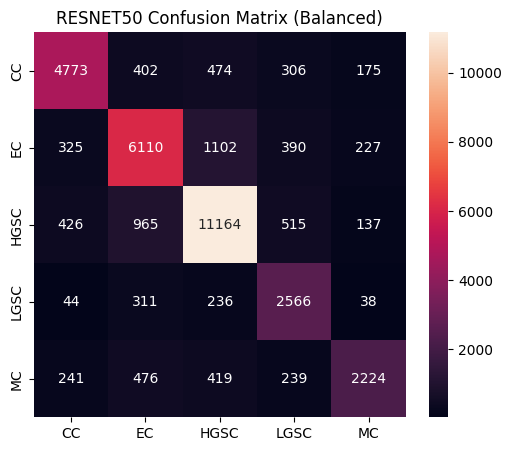

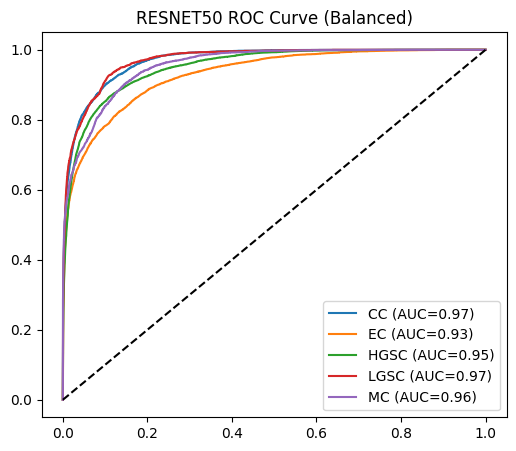


        RUNNING MODEL: DENSENET121 (BALANCED)
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 192MB/s]
densenet121 Fold 5 Epoch 5: 100%|██████████| 286/286 [02:03<00:00,  2.32it/s]



FINAL RESULTS (BALANCED)
Accuracy          : 0.8120
Balanced Accuracy : 0.8118
Macro F1          : 0.8110
Macro AUC         : 0.9688


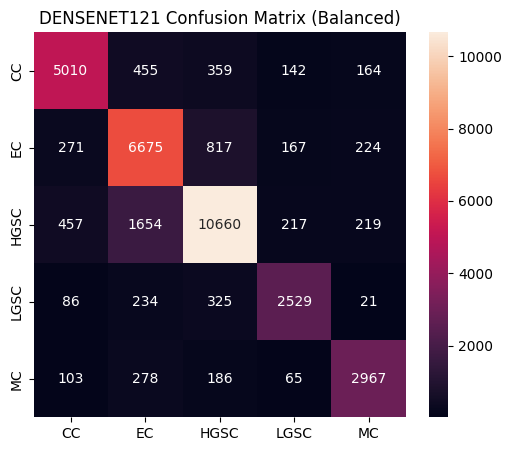

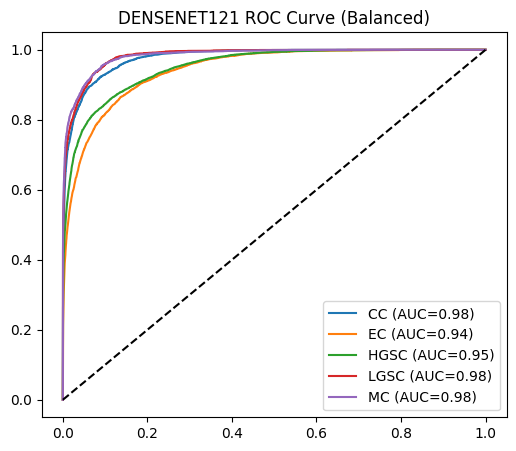


        RUNNING MODEL: MOBILENETV3 (BALANCED)
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 161MB/s]
mobilenetv3 Fold 5 Epoch 5: 100%|██████████| 286/286 [01:39<00:00,  2.86it/s]



FINAL RESULTS (BALANCED)
Accuracy          : 0.8846
Balanced Accuracy : 0.8642
Macro F1          : 0.8721
Macro AUC         : 0.9868


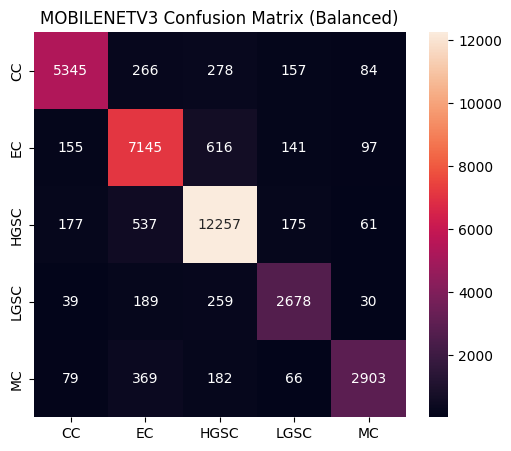

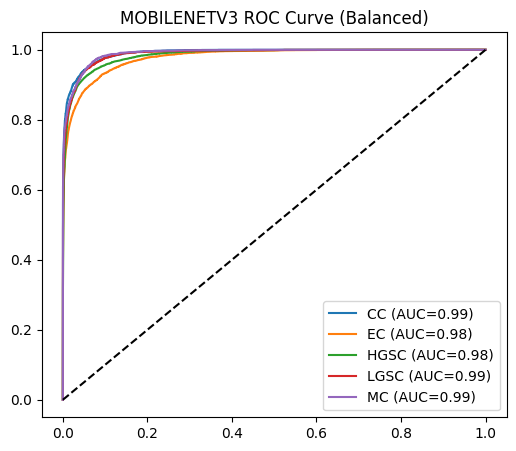


        RUNNING MODEL: EFFICIENTNET (BALANCED)


efficientnet Fold 5 Epoch 5: 100%|██████████| 286/286 [01:42<00:00,  2.79it/s]



FINAL RESULTS (BALANCED)
Accuracy          : 0.9182
Balanced Accuracy : 0.9098
Macro F1          : 0.9086
Macro AUC         : 0.9934


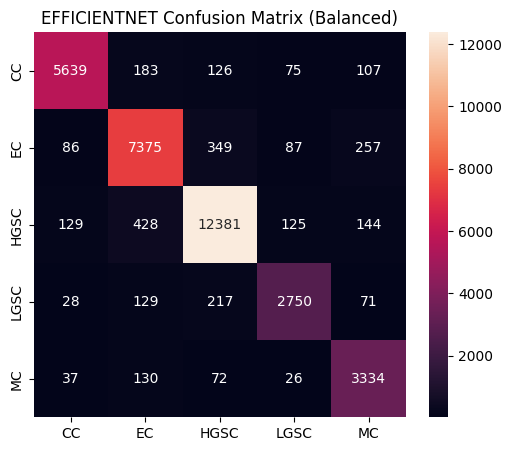

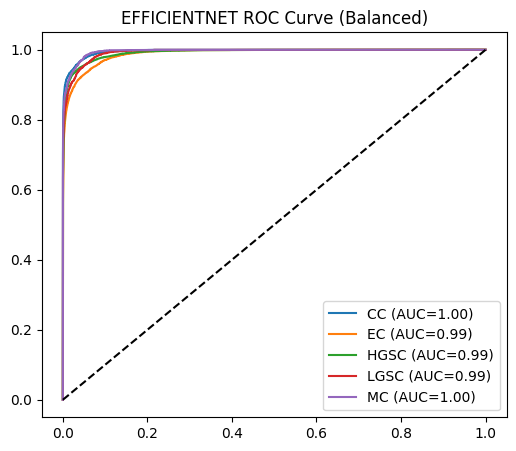

In [19]:
# ============================================================
# BACKBONE COMPARISON (BALANCED DATASET — SAME AS MAIN PIPELINE)
# ============================================================

from sklearn.metrics import roc_curve, auc

# ---------------- MODEL FACTORY ----------------
def get_model(name, num_classes):

    if name == "resnet50":
        m = models.resnet50(weights="IMAGENET1K_V1")
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m

    if name == "densenet121":
        m = models.densenet121(weights="IMAGENET1K_V1")
        m.classifier = nn.Linear(m.classifier.in_features, num_classes)
        return m

    if name == "mobilenetv3":
        m = models.mobilenet_v3_large(weights="IMAGENET1K_V1")
        m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
        return m

    if name == "efficientnet":
        m = models.efficientnet_b0(weights="IMAGENET1K_V1")
        m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
        return m

# ============================================================
# FIX: Convert balanced dataset to numpy for StratifiedKFold
# ============================================================

files = np.array(files)
labels = np.array(labels)

print("Dataset converted to numpy arrays ✔")
print("files type  :", type(files))
print("labels type :", type(labels))
print("files shape :", files.shape)
print("labels shape:", labels.shape)
model_list = ["resnet50","densenet121","mobilenetv3","efficientnet"]

for model_name in model_list:

    print("\n" + "="*60)
    print(f"        RUNNING MODEL: {model_name.upper()} (BALANCED)")
    print("="*60)

    fold_acc, fold_bacc, fold_f1, fold_auc = [],[],[],[]
    all_preds, all_gts, all_probs = [],[],[]

    for fold,(tr,va) in enumerate(skf.split(files,labels),1):

        train_ds = HistoDataset(files[tr],labels[tr],train_tf)
        val_ds   = HistoDataset(files[va],labels[va],val_tf)

        train_loader = DataLoader(train_ds,BATCH_SIZE,True,num_workers=2,pin_memory=True)
        val_loader   = DataLoader(val_ds,BATCH_SIZE,False,num_workers=2,pin_memory=True)

        model = get_model(model_name,len(classes)).to(device)

        optimizer = optim.AdamW(model.parameters(),lr=3e-4)
        scaler = torch.cuda.amp.GradScaler()
        criterion = nn.CrossEntropyLoss()

        # -------- TRAIN --------
        for epoch in range(5):
            model.train()
            for x,y in tqdm(train_loader,desc=f"{model_name} Fold {fold} Epoch {epoch+1}"):
                x,y = x.to(device), y.to(device)

                optimizer.zero_grad()
                with torch.amp.autocast("cuda"):
                    out = model(x)
                    loss = criterion(out,y)

                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        # -------- VALIDATION --------
        model.eval()
        preds,gts,probs=[],[],[]

        with torch.no_grad():
            for x,y in val_loader:
                x = x.to(device)
                with torch.amp.autocast("cuda"):
                    out=model(x)

                p = out.softmax(1).cpu().numpy()
                probs.extend(p)
                preds.extend(out.argmax(1).cpu().numpy())
                gts.extend(y.numpy())

        acc  = accuracy_score(gts,preds)
        bacc = balanced_accuracy_score(gts,preds)
        f1m  = f1_score(gts,preds,average="macro")
        aucv = roc_auc_score(label_binarize(gts,classes=range(len(classes))),probs,average="macro",multi_class="ovr")

        fold_acc.append(acc); fold_bacc.append(bacc); fold_f1.append(f1m); fold_auc.append(aucv)

        all_preds.extend(preds)
        all_gts.extend(gts)
        all_probs.extend(probs)

    # -------- FINAL MEAN METRICS --------
    print("\nFINAL RESULTS (BALANCED)")
    print(f"Accuracy          : {np.mean(fold_acc):.4f}")
    print(f"Balanced Accuracy : {np.mean(fold_bacc):.4f}")
    print(f"Macro F1          : {np.mean(fold_f1):.4f}")
    print(f"Macro AUC         : {np.mean(fold_auc):.4f}")

    # -------- CONFUSION MATRIX --------
    cm = confusion_matrix(all_gts,all_preds)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,fmt="d",xticklabels=classes,yticklabels=classes)
    plt.title(f"{model_name.upper()} Confusion Matrix (Balanced)")
    plt.show()

    # -------- ROC CURVE --------
    y_true_bin = label_binarize(all_gts, classes=range(len(classes)))

    plt.figure(figsize=(6,5))
    for i in range(len(classes)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], np.array(all_probs)[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.2f})")

    plt.plot([0,1],[0,1],'k--')
    plt.title(f"{model_name.upper()} ROC Curve (Balanced)")
    plt.legend()
    plt.show()